In [19]:
import csv
import matplotlib.pyplot as plt

infile = open("../data/unlinked_bicores/5Msample_1MHz_power_on_2_stripped.csv", 'r')


reader = csv.DictReader(infile)
times = []
logic0 = []
logic1 = []
for entry in reader:
    times.append(entry["microseconds"])
    logic0.append(entry["logic0"])
    logic1.append(entry["logic1"])

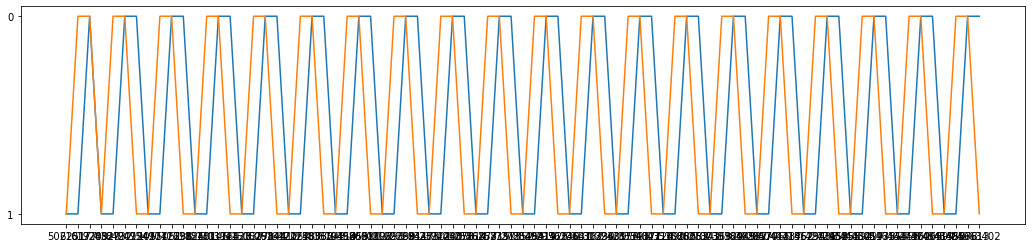

In [20]:
plt.figure(figsize=(18,4))
plt.plot(times, logic0, logic1)

The stripped version of the csv files only keeps the entries where one of the values changed, so the rising and falling edges look like slopes instead of a square wave. One way to handle that would be to fill in the data that was stripped and use the filled in version to produce the graphs. 

The other is to not really worry about the graphs immediately. One thing to look at is the frequency of each of the two waves, another is to figure out the phase relationship between the two square waves. My suspicion is that the phase is 180 degrees, which is weird given that the two bicores are not supposed to be connected. 

So how do you measure the phase difference of two square waves? Phase is the relative displacement between two waves with respect to one another. The time difference of the waves can be said to be the difference between two successive rising edges. Assuming they are the same frequency, the phase difference is the time difference between two rising edges, divided by the time of one cycle (so distance into the cycle as a ratio), multiplied by $2\pi$ to get a phase angle. 

Given the data I have, I'd have to find the frequency for both channels. Then I'd find the first rising edge in either of the channels, then the next (chronologically) rising edge in the other channel, get the difference, and then the ratio based on the frequency and calculate the phase angle. Repeat that for each set of subsequent rising edges, and then graph the results.  

[230145, 230427, 227936, 228730, 228347, 229479, 228408, 228576, 228578, 228176, 229525, 228534, 228673, 227814, 228057, 229360, 228864, 227092]
228706.72222222222
830.712012500372


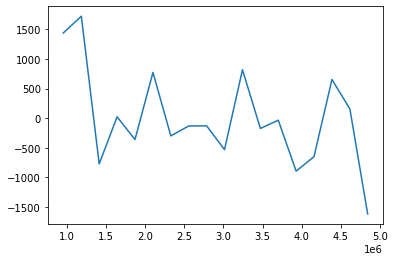

In [31]:
prev_v = None
rising_times = []
for t, v in zip(times, logic0):
    if prev_v is None:
        prev_v = v
    # Rising edges
    if prev_v != v and v == '1':
        rising_times.append(int(t))
    prev_v = v

starts = rising_times[1:]
ends = rising_times[:-1]
delta_t = [s - e for s, e in zip(starts, ends)]

import statistics
print(statistics.mean(delta_t))
print(statistics.stdev(delta_t))

plt.plot(starts, [d - statistics.mean(delta_t) for d in delta_t])

In [32]:
1000000/228706.72

4.372411969355339

The mean period of 228706.72ms means a frequency of 1000000/228706.72 = 4.37Hz

A problem arises when one of the signals is not of consistent frequency. At that point, the use of rising edges doesn't make sense for measurement of phase angle because there isn't a 1-to-1 correspondance of rising edges. 

I can pretty much graph "instantaneous frequency" based on the distance between subsequent rising edges, and only look at sections where the frequencies are approximately the same. The thing I'm trying to figure out here is whether the two bicores are falling into synchrony despite being disconnected, but in a rigorous way, rather than looking at pictures. 